# Análisis de Finanzas y Riesgo crediticio

## En quina mesura els clients amb saldos més baixos estan en més risc d'incompliment de crèdit, i com hem d'ajustar les nostres polítiques de crèdit per mitigar aquest risc?

### Librerias

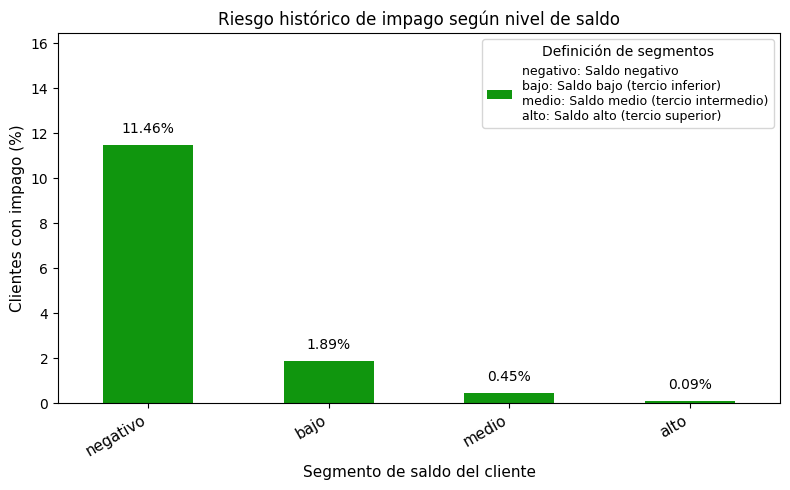

In [123]:
import matplotlib.pyplot as plt

# Datos para el gráfico principal
default_main = (
    df
    .groupby("balance_segment")["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .reindex(["negativo", "bajo", "medio", "alto"])
)

# Descripción de los segmentos de balance
balance_intervals = {
    "negativo": "Saldo negativo",
    "bajo": "Saldo bajo (tercio inferior)",
    "medio": "Saldo medio (tercio intermedio)",
    "alto": "Saldo alto (tercio superior)"
}

# Parámetros visuales estándar
FIG_SIZE = (8, 5)
BAR_COLOR = "#10960E"

# Crear gráfico
plt.figure(figsize=FIG_SIZE)
ax = default_main.plot(kind="bar", color=BAR_COLOR)

# Etiquetas y título
ax.set_xlabel("Segmento de saldo del cliente", fontsize=11)
ax.set_ylabel("Clientes con impago (%)", fontsize=11)
ax.set_title("Riesgo histórico de impago según nivel de saldo", fontsize=12)

# Etiquetas del eje X más grandes y en diagonal
ax.set_xticklabels(
    default_main.index,
    rotation=30,
    ha="right",
    fontsize=11
)

# Etiquetas de valor sobre las barras
for i, value in enumerate(default_main):
    ax.text(
        i,
        value + 0.4,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Ajustar eje Y
ax.set_ylim(0, default_main.max() + 5)

# Leyenda explicativa de segmentos
legend_text = "\n".join(
    [f"{seg}: {desc}" for seg, desc in balance_intervals.items()]
)

plt.legend(
    [legend_text],
    title="Definición de segmentos",
    loc="upper right",
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()


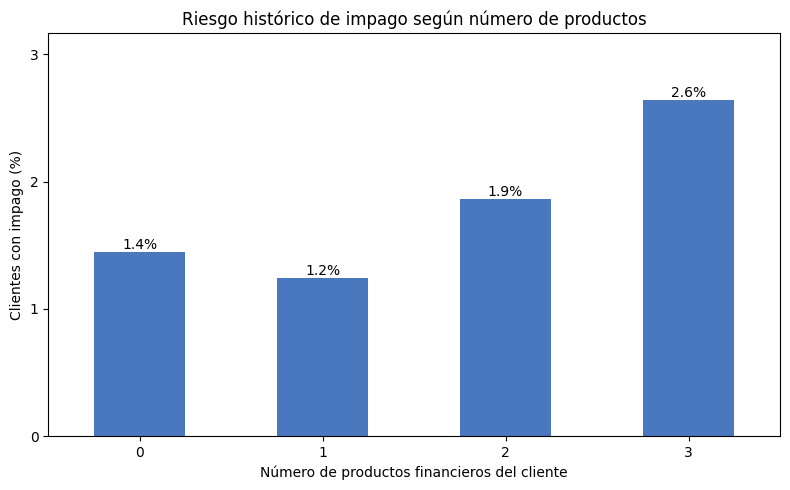

In [ ]:
# NUEVO GRAFICO 3.A.4.

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

FIG_SIZE = (8, 5)
BAR_COLOR = "#4978BE"

default_by_products = (
    df
    .groupby("num_products")["credit_default"]
    .mean()
    * 100
)

plt.figure(figsize=FIG_SIZE)
ax = default_by_products.plot(kind="bar", color=BAR_COLOR)

ax.set_title("Riesgo histórico de impago según número de productos")
ax.set_xlabel("Número de productos financieros del cliente")
ax.set_ylabel("Clientes con impago (%)")

# Asse Y: numeri interi
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Eje X: etiquetas horizontales
ax.set_xticklabels(
    default_by_products.index,
    rotation=0,
    ha="center",
    fontsize=10
)

# Etiquetas en las barras
for p in ax.patches:
    value = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylim(0, default_by_products.max() * 1.2)

plt.tight_layout()
plt.show()


In [131]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

### Import dataset

In [132]:
# Ruta CSV 
data_path = "../Data/Silver_BANK_marketing_190126.csv"

# Cargar el dataset
df = pd.read_csv(
    data_path,
    sep=",",
    encoding="utf-8"
)

# Verificar dimensiones iniciales
df.shape


(10643, 18)

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10643 entries, 0 to 10642
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10643 non-null  int64  
 1   age             10634 non-null  float64
 2   job             10643 non-null  object 
 3   marital         10643 non-null  object 
 4   education       10643 non-null  object 
 5   credit_default  10643 non-null  int64  
 6   balance         10643 non-null  int64  
 7   housing         10643 non-null  int64  
 8   loan            10643 non-null  int64  
 9   contact         10643 non-null  object 
 10  day             10643 non-null  int64  
 11  month           10643 non-null  object 
 12  duration        10643 non-null  int64  
 13  campaign        10643 non-null  int64  
 14  pdays           10643 non-null  int64  
 15  previous        10643 non-null  int64  
 16  poutcome        10643 non-null  object 
 17  deposit         10643 non-null 

In [134]:
df.head()

,id,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,2,59.0,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
2,3,56.0,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1
3,4,41.0,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1
4,5,55.0,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1


### Data Understanding

La variable clave para analizar los **saldos bajos es "balance"**, mientras que por otro lado, la variable que nos puede indicar el nivel de **riesgo crediticio es el campo "credit_default"** que nos indica si el cliente cuenta con un historial de impagos. Adicionalmente, habrá que analizar si la contratación de unos **(A) productos financieros** u otros (deposit, loan, housing) implican mayor o menor riesgo, así como también el impacto que tiene el tipo de **(B) perfil sociodemográfico** (age, education, job, marital) en dicho riesgo. 

### Exploratory Data Analysis - EDA

### Análisis de variables relevantes

#### 1. Credit default

In [135]:
# Conteo y %
df["credit_default"].value_counts(), df["credit_default"].value_counts(normalize=True) * 100

(credit_default
 0    10488
 1      155
 Name: count, dtype: int64,
 credit_default
 0    98.543644
 1     1.456356
 Name: proportion, dtype: float64)

#### 2. Balance

In [136]:
# Estadísticas descriptivas ampliadas de balance
df["balance"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99])


count    10643.000000
mean      1536.690595
std       3223.277326
min      -6847.000000
1%        -516.480000
5%         -48.800000
10%          0.000000
25%        127.000000
50%        558.000000
75%       1729.500000
90%       3911.200000
95%       6004.900000
99%      13101.540000
max      81204.000000
Name: balance, dtype: float64

#### A. Productos financieros - deposit, loan & housing

In [137]:
# Count y pct por producto
def counts_with_pct(series):
    counts = series.value_counts(dropna=False)
    pct = series.value_counts(dropna=False, normalize=True).mul(100).round(2)
    return pd.DataFrame({"count": counts, "pct": pct})

display(counts_with_pct(df["deposit"]))
display(counts_with_pct(df["loan"]))
display(counts_with_pct(df["housing"]))

,count,pct
deposit,,
0,5353,50.3
1,5290,49.7


,count,pct
loan,,
0,9271,87.11
1,1372,12.89


,count,pct
housing,,
0,5660,53.18
1,4983,46.82


#### B. Perfil sociodemográfico - age, education, job, marital

In [138]:
# Verificar rango de edad
df["age"].describe()

count    10634.000000
mean        41.254279
std         12.003685
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

In [139]:
df["age"].isna().sum()

np.int64(9)

In [140]:
# Count y pct de categorías en education
pd.DataFrame({
    "count": df["education"].value_counts(),
    "pct": df["education"].value_counts(normalize=True).mul(100).round(2)
})

,count,pct
education,,
secondary,5217,49.02
tertiary,3527,33.14
primary,1419,13.33
unknown,480,4.51


In [141]:
# Count y pct de categorías en job
pd.DataFrame({
    "count": df["job"].value_counts(dropna=False),
    "pct": df["job"].value_counts(dropna=False, normalize=True).mul(100).round(2)
})

,count,pct
job,,
management,2447,22.99
blue-collar,1830,17.19
technician,1737,16.32
admin.,1280,12.03
services,881,8.28
retired,755,7.09
self-employed,388,3.65
student,354,3.33
unemployed,338,3.18


In [142]:
# Count y pct de categorías en marital
pd.DataFrame({
    "count": df["marital"].value_counts(dropna=False),
    "pct": df["marital"].value_counts(dropna=False, normalize=True).mul(100).round(2)
})

,count,pct
marital,,
married,6031,56.67
single,3374,31.70
divorced,1233,11.59
unknown,5,0.05


### Data Transformation and Data Reduction

#### 1. Creación de columna balance_segment

In [143]:
# Crear columna de segmentación de balance
df["balance_segment"] = np.nan

# Segmento negativo
df.loc[df["balance"] < 0, "balance_segment"] = "negativo" # Tener un saldo negativo implica estar en descubierto, 
                                                          # indicador grave de estrés económico por lo que el riesgo es muu alto.

# Segmento cero + positivo (agrupamos los saldo 0 con los positivos ya que consideramos que tener 0 saldo no supone un riesgo en sí mismo, 
# pese a que no sea un indicador de solvencia fuerte.)
non_negative_mask = df["balance"] >= 0

# Subsegmentar cero y positivos en tres grupos
df.loc[non_negative_mask, "balance_segment"] = pd.qcut(
    df.loc[non_negative_mask, "balance"],
    q=3,
    labels=["bajo", "medio", "alto"])

/var/folders/76/wztx28d52kx8nb4cvhv6r63h0000gn/T/ipykernel_2841/859896497.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'negativo' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["balance"] < 0, "balance_segment"] = "negativo" # Tener un saldo negativo implica estar en descubierto,


In [144]:
# Verificar distribución de los segmentos
df["balance_segment"].value_counts()

balance_segment
bajo        3338
alto        3333
medio       3326
negativo     646
Name: count, dtype: int64

In [145]:
# Proporción de clientes por tipo de balance
balance_area_summary = pd.Series({
    "negativo": (df["balance"] < 0).mean() * 100,
    "cero": (df["balance"] == 0).mean() * 100,
    "positivo": (df["balance"] > 0).mean() * 100
}).round(2)

balance_area_summary

negativo     6.07
cero         6.83
positivo    87.10
dtype: float64

In [146]:
# Estadísticas solo balances positivos
df.loc[df["balance"] > 0, "balance"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])

count     9270.000000
mean      1786.734412
std       3380.539232
min          1.000000
10%         85.000000
25%        262.000000
50%        740.000000
75%       2037.000000
90%       4333.000000
max      81204.000000
Name: balance, dtype: float64

#### 2. Creación de columna age_group

In [147]:
# Crear grupos de edad
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "60+"])

In [148]:
# Verificar distribución de los segmentos
df["age_group"].value_counts()

age_group
31-45    5228
46-60    2867
18-30    1925
60+       606
Name: count, dtype: int64

### 3. Análisis de riesgo crediticio (balance_segment & credit_default)

In [149]:
# Tamaño del grupo balance_segment y porcentaje de default
balance_segment_summary = (
    df
    .groupby("balance_segment")
    .agg(
        total_clientes=("credit_default", "count"),
        porcentaje_default=("credit_default", lambda x: round(x.mean() * 100, 2))
    )
    .sort_values(by="porcentaje_default", ascending=False)
)

balance_segment_summary

,total_clientes,porcentaje_default
balance_segment,,
negativo,646,11.46
bajo,3338,1.89
medio,3326,0.45
alto,3333,0.09


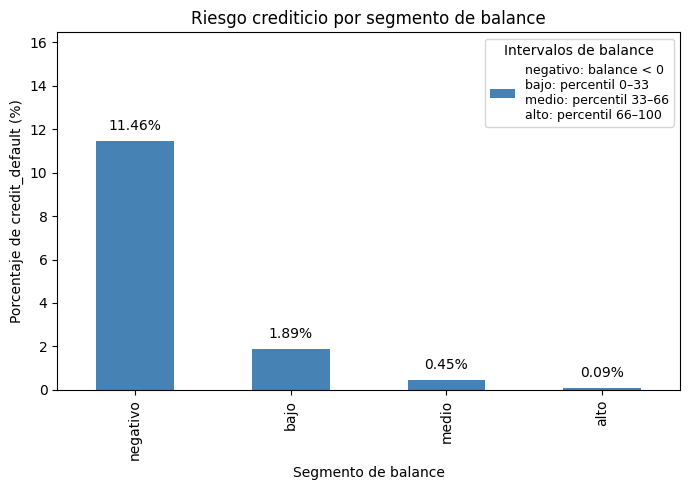

In [150]:
# Datos para el gráfico principal
default_main = (
    df
    .groupby("balance_segment")["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .reindex(["negativo", "bajo", "medio", "alto"])
)

# Diccionario con los intervalos numéricos de cada segmento
balance_intervals = {
    "negativo": "balance < 0",
    "bajo": "percentil 0–33",
    "medio": "percentil 33–66",
    "alto": "percentil 66–100"
}

# Gráfico de barras
plt.figure(figsize=(7, 5))
ax = default_main.plot(kind="bar", color="steelblue")

plt.ylabel("Porcentaje de credit_default (%)")
plt.xlabel("Segmento de balance")
plt.title("Riesgo crediticio por segmento de balance")

# Añadir labels encima de cada barra
for i, value in enumerate(default_main):
    ax.text(i, value + 0.5, f"{value}%", ha="center", fontsize=10)

# Ajustar el eje Y para que entren los textos
ax.set_ylim(0, default_main.max() + 5)

# Crear leyenda explicativa sin color
legend_text = "\n".join([f"{seg}: {desc}" for seg, desc in balance_intervals.items()])
plt.legend(
    [legend_text],
    title="Intervalos de balance",
    loc="upper right",
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

#### 3.A. Riesgo crediticio por producto financiero

##### 3.A.1. Riesgo crediticio vs deposit 

In [151]:
# Tabla balance_segment x deposit (% credit_default)
default_by_balance_deposit = (
    df
    .groupby(["balance_segment", "deposit"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)
default_by_balance_deposit.rename(
    columns={
        0: "deposit_no_%default",
        1: "deposit_yes_%default"
    },
    inplace=True
)
default_by_balance_deposit

deposit,deposit_no_%default,deposit_yes_%default
balance_segment,,
alto,0.14,0.05
bajo,2.41,1.19
medio,0.56,0.35
negativo,10.55,13.33


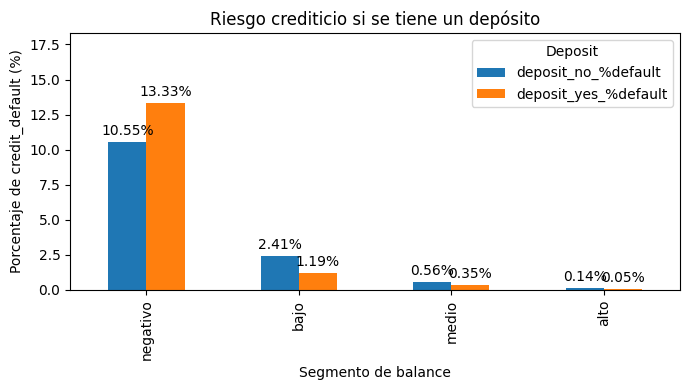

In [152]:
# Reordenar filas para coherencia visual
plot_deposit = default_by_balance_deposit.reindex(
    ["negativo", "bajo", "medio", "alto"]
)

# Crear gráfico
ax = plot_deposit.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Porcentaje de credit_default (%)")
plt.xlabel("Segmento de balance")
plt.title("Riesgo crediticio si se tiene un depósito")
plt.legend(title="Deposit")

# --- VALUE LABELS (solo esto añadido) ---
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

# Ajustar eje Y para que entren las etiquetas
ax.set_ylim(0, plot_deposit.max().max() + 5)

plt.tight_layout()
plt.show()

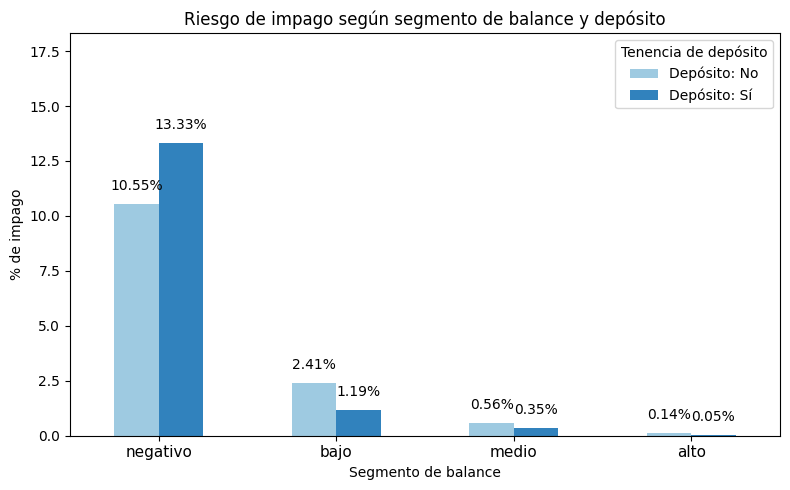

In [153]:
# NUEVO GRAFICO 3.A.1.
import matplotlib.pyplot as plt

# Reordenar filas para coherencia visual
plot_deposit = default_by_balance_deposit.reindex(
    ["negativo", "bajo", "medio", "alto"]
)

# Colores: mismo azul, distinta intensidad
COLORS = ["#9ecae1", "#3182bd"]  # claro = No, oscuro = Sí

#  gráfico
ax = plot_deposit.plot(
    kind="bar",
    figsize=(8, 5),
    color=COLORS
)

# Etiquetas y título
ax.set_ylabel("% de impago")
ax.set_xlabel("Segmento de balance")
ax.set_title("Riesgo de impago según segmento de balance y depósito")

# Eje X: etiquetas horizontales
ax.set_xticklabels(
    plot_deposit.index,
    rotation=0,
    fontsize=11
)

# Leyenda 
ax.legend(
    ["Depósito: No", "Depósito: Sí"],
    title="Tenencia de depósito"
)

# Etiquetas de valor sobre las barras
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Ajustar eje Y
ax.set_ylim(0, plot_deposit.max().max() + 5)

plt.tight_layout()
plt.show()


##### 3.A.2. Riesgo crediticio vs loan 

In [154]:
# Tabla balance_segment x loan (% credit_default)
default_by_balance_loan = (
    df
    .groupby(["balance_segment", "loan"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)
default_by_balance_loan.rename(
    columns={
        0: "loan_no_%default",
        1: "loan_yes_%default"
    },
    inplace=True
)
default_by_balance_loan

loan,loan_no_%default,loan_yes_%default
balance_segment,,
alto,0.10,0.00
bajo,1.40,4.70
medio,0.38,0.94
negativo,10.63,13.24


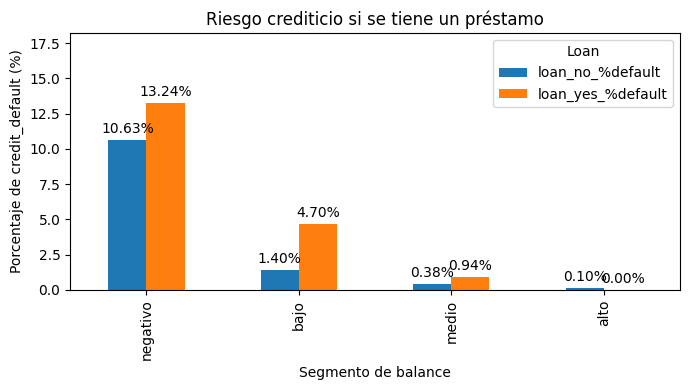

In [155]:
# Reordenar filas para coherencia visual
plot_loan = default_by_balance_loan.reindex(
    ["negativo", "bajo", "medio", "alto"]
)

# Crear gráfico
ax = plot_loan.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Porcentaje de credit_default (%)")
plt.xlabel("Segmento de balance")
plt.title("Riesgo crediticio si se tiene un préstamo")
plt.legend(title="Loan")

# --- VALUE LABELS ---
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

# Ajustar eje Y para que entren las etiquetas
ax.set_ylim(0, plot_loan.max().max() + 5)

plt.tight_layout()
plt.show()

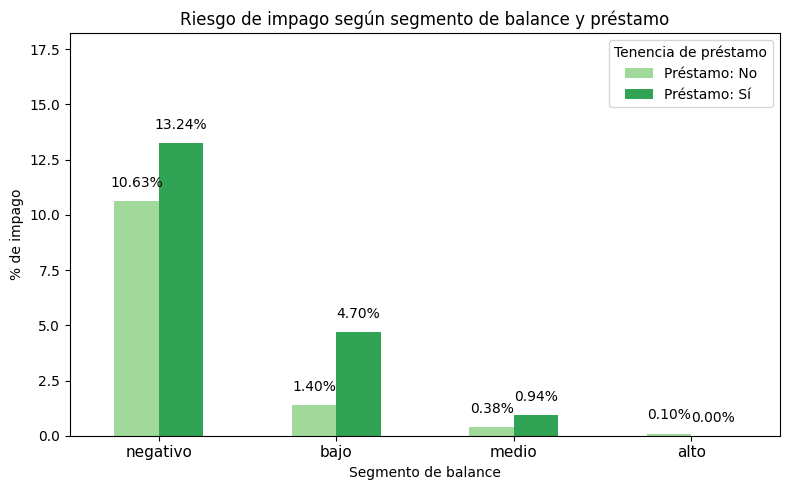

In [156]:
# NUEVO GRAFICO 3.A.2.

import matplotlib.pyplot as plt

# Reordenar filas para coherencia visual
plot_loan = default_by_balance_loan.reindex(
    ["negativo", "bajo", "medio", "alto"]
)

# Colores: mismo verde, distinta intensidad
COLORS = ["#a1d99b", "#31a354"]  # claro = No, oscuro = Sí

# Crear gráfico
ax = plot_loan.plot(
    kind="bar",
    figsize=(8, 5),
    color=COLORS
)

# Etiquetas y título
ax.set_ylabel("% de impago")
ax.set_xlabel("Segmento de balance")
ax.set_title("Riesgo de impago según segmento de balance y préstamo")

# Eje X: etiquetas horizontales
ax.set_xticklabels(
    plot_loan.index,
    rotation=0,
    fontsize=11
)

# Leyenda clara
ax.legend(
    ["Préstamo: No", "Préstamo: Sí"],
    title="Tenencia de préstamo"
)

# Etiquetas de valor sobre las barras
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Ajustar eje Y
ax.set_ylim(0, plot_loan.max().max() + 5)

plt.tight_layout()
plt.show()



##### 3.A.3. Riesgo crediticio vs housing

In [157]:
# Tabla balance_segment x housing 
default_by_balance_housing = (
    df
    .groupby(["balance_segment", "housing"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)


default_by_balance_housing.rename(
    columns={
        0: "housing_no_%default",
        1: "housing_yes_%default"
    },
    inplace=True
)

default_by_balance_housing

housing,housing_no_%default,housing_yes_%default
balance_segment,,
alto,0.00,0.23
bajo,2.52,1.19
medio,0.40,0.51
negativo,14.63,10.37


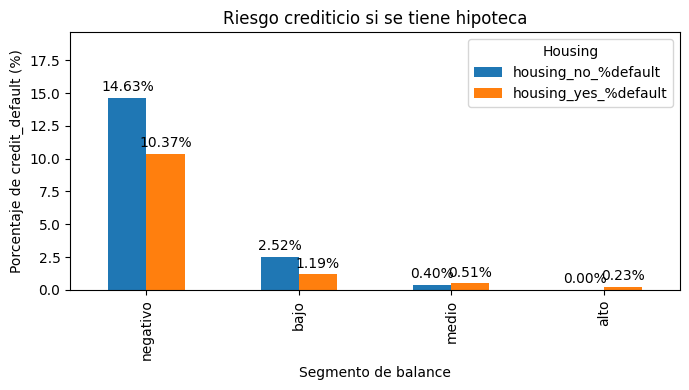

In [158]:
# Reordenar filas para coherencia visual
plot_housing = default_by_balance_housing.reindex(
    ["negativo", "bajo", "medio", "alto"]
)

# Crear gráfico
ax = plot_housing.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Porcentaje de credit_default (%)")
plt.xlabel("Segmento de balance")
plt.title("Riesgo crediticio si se tiene hipoteca")
plt.legend(title="Housing")

# --- VALUE LABELS ---
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

# Ajustar eje Y para que entren las etiquetas
ax.set_ylim(0, plot_housing.max().max() + 5)

plt.tight_layout()
plt.show()

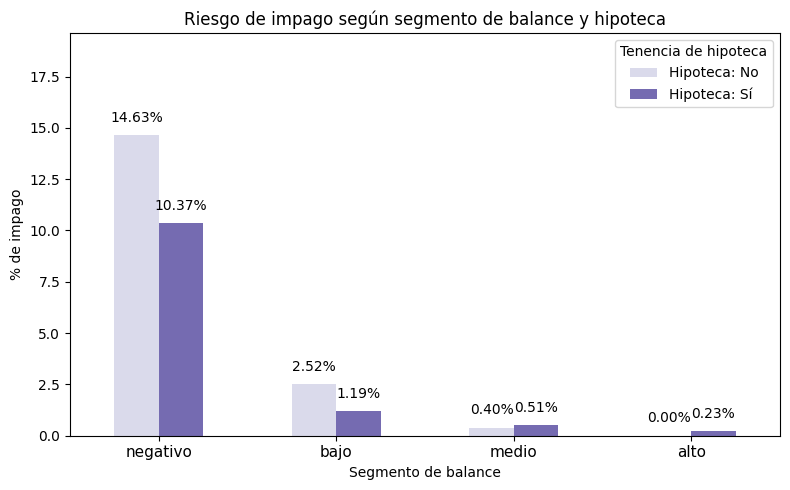

In [159]:
# NUEVO GRAFICO 3.A.3.

import matplotlib.pyplot as plt

# Reordenar filas para coherencia visual
plot_housing = default_by_balance_housing.reindex(
    ["negativo", "bajo", "medio", "alto"]
)

# Colores: mismo lila, distinta intensidad
COLORS = ["#dadaeb", "#756bb1"]  # claro = No, oscuro = Sí

# Crear gráfico
ax = plot_housing.plot(
    kind="bar",
    figsize=(8, 5),
    color=COLORS
)

# Etiquetas y título
ax.set_ylabel("% de impago")
ax.set_xlabel("Segmento de balance")
ax.set_title("Riesgo de impago según segmento de balance y hipoteca")

# Eje X: etiquetas horizontales
ax.set_xticklabels(
    plot_housing.index,
    rotation=0,
    fontsize=11
)

# Leyenda clara
ax.legend(
    ["Hipoteca: No", "Hipoteca: Sí"],
    title="Tenencia de hipoteca"
)

# Etiquetas de valor sobre las barras
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Ajustar eje Y
ax.set_ylim(0, plot_housing.max().max() + 5)

plt.tight_layout()
plt.show()


##### 3.A.4. Riesgo crediticio por grado de vinculación

In [160]:
df["num_products"] = df[["housing", "loan", "deposit"]].sum(axis=1)

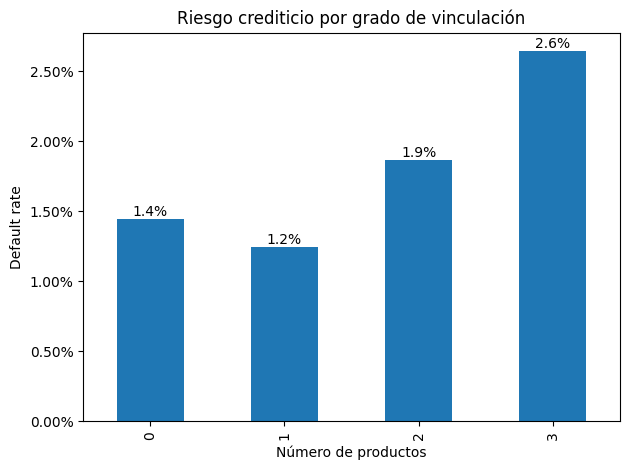

In [161]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

ax = df.groupby("num_products")["credit_default"].mean().plot(kind="bar")

plt.title("Riesgo crediticio por grado de vinculación")
plt.ylabel("Default rate")
plt.xlabel("Número de productos")

# Eix Y en percentatge (valors entre 0 i 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Etiquetes en percentatge a sobre de cada barra
for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value*100:.1f}%",
                (p.get_x() + p.get_width() / 2, value),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [162]:
print(df.columns)


Index(['id', 'age', 'job', 'marital', 'education', 'credit_default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'deposit', 'balance_segment',
       'age_group', 'num_products'],
      dtype='object')


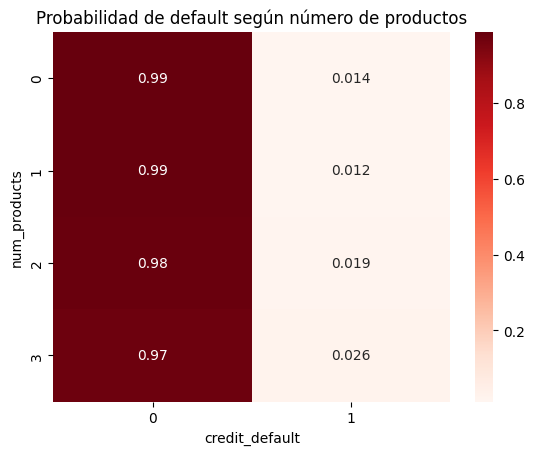

In [163]:
tabla = pd.crosstab(df["num_products"], df["credit_default"], normalize="index")
sns.heatmap(tabla, annot=True, cmap="Reds")
plt.title("Probabilidad de default según número de productos")
plt.show()

#### 3.B. Riesgo crediticio por perfil sociodemográfico

#####  3.B.1. Riesgo crediticio vs age group

In [164]:
# Tabla balance_segment x age_group (% credit_default)
default_by_balance_age = (
    df
    .groupby(["balance_segment", "age_group"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

default_by_balance_age

/var/folders/76/wztx28d52kx8nb4cvhv6r63h0000gn/T/ipykernel_2841/575315440.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["balance_segment", "age_group"])["credit_default"]


age_group,18-30,31-45,46-60,60+
balance_segment,,,,
alto,0.21,0.00,0.20,0.00
bajo,2.42,1.72,2.09,0.00
medio,0.30,0.43,0.58,0.61
negativo,11.02,10.95,12.85,0.00


/var/folders/76/wztx28d52kx8nb4cvhv6r63h0000gn/T/ipykernel_2841/632143482.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["balance_segment", "age_group"])["credit_default"]


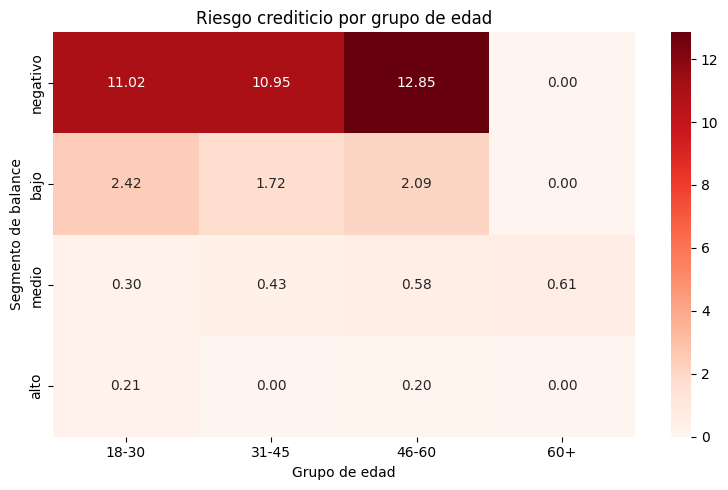

In [165]:
balance_order = ["negativo", "bajo", "medio", "alto"]

heatmap_age = (
    df
    .groupby(["balance_segment", "age_group"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
    .reindex(balance_order)
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_age,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Riesgo crediticio por grupo de edad")
plt.ylabel("Segmento de balance")
plt.xlabel("Grupo de edad")
plt.tight_layout()
plt.show()

#####  3.B.2. Riesgo crediticio vs education

In [166]:
# Tabla balance_segment x education (% credit_default)
default_by_balance_education = (
    df
    .groupby(["balance_segment", "education"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
    .reindex(["negativo", "bajo", "medio", "alto"])
)

default_by_balance_education

education,primary,secondary,tertiary,unknown
balance_segment,,,,
negativo,14.29,10.37,9.63,31.25
bajo,1.98,1.71,1.98,3.03
medio,0.77,0.41,0.47,0.00
alto,0.00,0.14,0.08,0.00


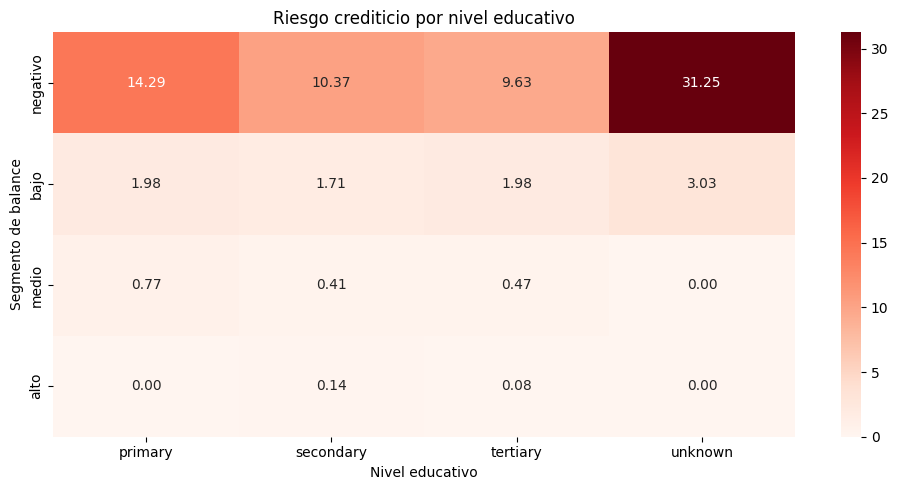

In [167]:
plt.figure(figsize=(10, 5))
sns.heatmap(
    default_by_balance_education,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Riesgo crediticio por nivel educativo")
plt.ylabel("Segmento de balance")
plt.xlabel("Nivel educativo")
plt.tight_layout()
plt.show()


#####  3.B.3. Riesgo crediticio vs job


In [168]:
# Tabla balance_segment x job (% credit_default)
default_by_balance_job = (
    df
    .groupby(["balance_segment", "job"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
    .reindex(["negativo", "bajo", "medio", "alto"])
)

default_by_balance_job

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
balance_segment,,,,,,,,,,,,
negativo,3.49,13.27,26.92,33.33,9.28,9.52,11.11,6.33,NaN,12.75,33.33,NaN
bajo,1.13,1.57,2.80,2.91,2.43,1.24,3.94,0.34,0.77,2.22,3.06,5.88
medio,0.00,0.85,0.00,3.28,0.55,0.47,0.00,0.35,0.00,0.36,0.00,0.00
alto,0.31,0.00,0.00,0.00,0.23,0.00,0.00,0.00,0.00,0.00,0.00,0.00


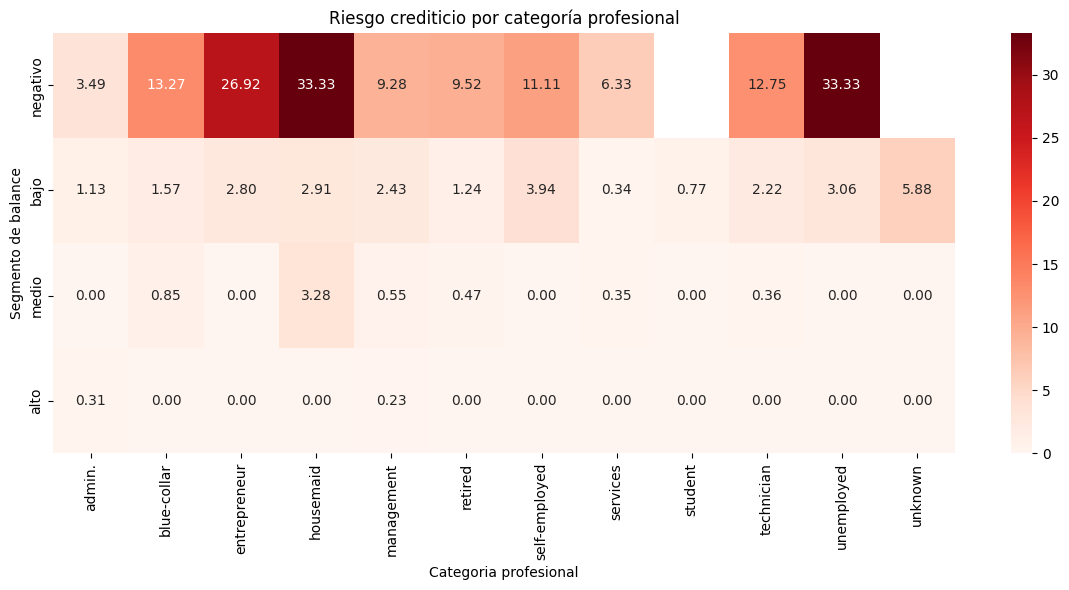

In [169]:
balance_order = ["negativo", "bajo", "medio", "alto"]


# Tabla para heatmap: balance_segment x job
heatmap_job = (
    df
    .groupby(["balance_segment", "job"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
    .reindex(balance_order)
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_job,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Riesgo crediticio por categoría profesional")
plt.ylabel("Segmento de balance")
plt.xlabel("Categoria profesional")
plt.tight_layout()
plt.show()

#####  3.B.4. Riesgo crediticio vs marital

In [170]:
# Tabla balance_segment x marital (% credit_default)
default_by_balance_marital = (
    df
    .groupby(["balance_segment", "marital"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
    .reindex(["negativo", "bajo", "medio", "alto"])
)

default_by_balance_marital

marital,divorced,married,single,unknown
balance_segment,,,,
negativo,9.09,11.42,13.07,0.0
bajo,2.91,1.77,1.70,0.0
medio,1.14,0.44,0.26,0.0
alto,0.28,0.05,0.10,0.0


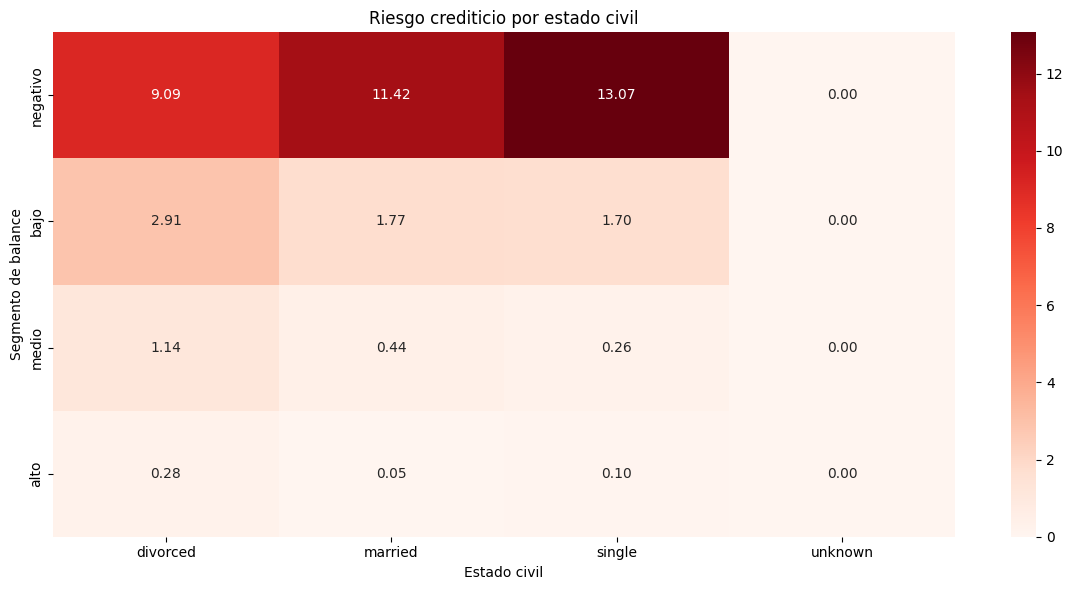

In [171]:
balance_order = ["negativo", "bajo", "medio", "alto"]


# Tabla para heatmap: balance_segment x marital
heatmap_marital = (
    df
    .groupby(["balance_segment", "marital"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
    .reindex(balance_order)
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_marital,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Riesgo crediticio por estado civil")
plt.ylabel("Segmento de balance")
plt.xlabel("Estado civil")
plt.tight_layout()
plt.show()

### 4. Análisis de correlaciones

#### 4.A. Matriz de correlación por productos financieros

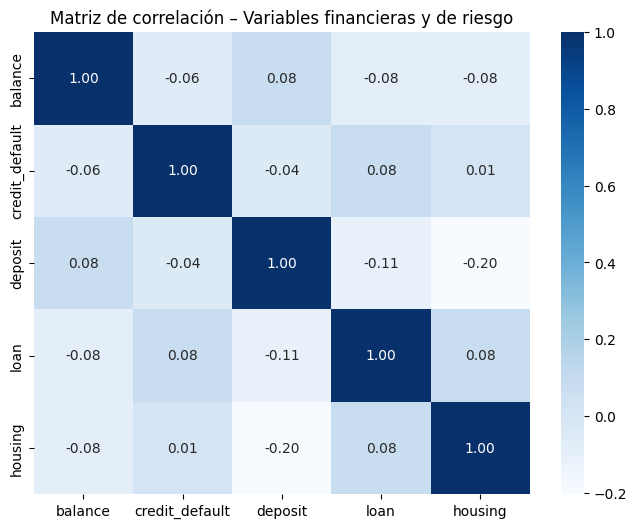

In [172]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selección de variables financieras / riesgo
vars_financieras = ["balance", "credit_default", "deposit", "loan", "housing"]

corr_fin = df[vars_financieras].corr(method="pearson")

plt.figure(figsize=(8,6))
sns.heatmap(corr_fin, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlación – Variables financieras y de riesgo")
plt.show()

#### 4.B. Matriz de correlación por perfil sociodemográfico

In [173]:
# Función para calcular Cramer’s 
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcula el coeficiente de Cramer entre dos variables categóricas."""
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

In [174]:
# Variables para la matriz demográfica
vars_demo = ["balance", "credit_default", "age_group", "education", "job", "marital"] 

In [175]:
# Creación de la matriz vacía
matriz_cramer = pd.DataFrame(
    np.zeros((len(vars_demo), len(vars_demo))),
    index=vars_demo,
    columns=vars_demo
)

# Incorporación de las variables
for v1 in vars_demo:
    for v2 in vars_demo:
        matriz_cramer.loc[v1, v2] = cramers_v(df[v1], df[v2])

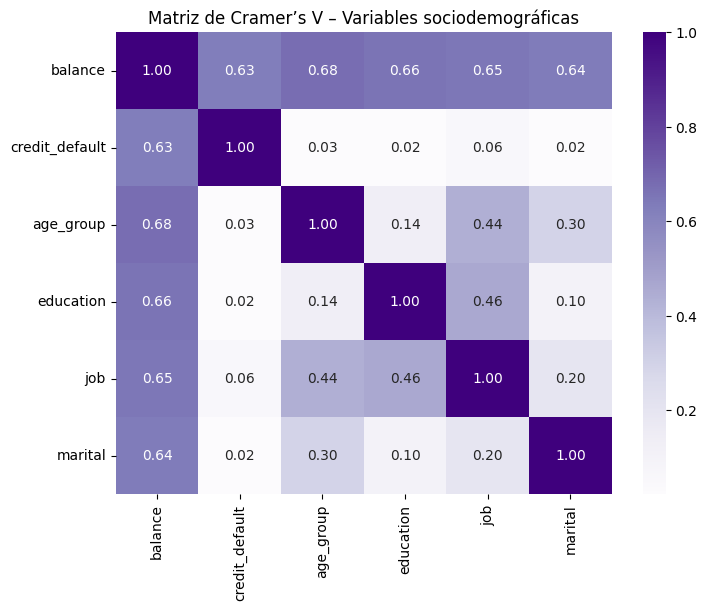

In [176]:
# Gráfico heatmap
plt.figure(figsize=(8,6))
sns.heatmap(matriz_cramer, annot=True, cmap="Purples", fmt=".2f")
plt.title("Matriz de Cramer’s V – Variables sociodemográficas")
plt.show()